# SECOM — Extra Trees vs Logistic Regression

### Models
- Logistic Regression (class-weighted)
- Extra Trees (class-weighted)

### methodology
- Official UCI SECOM download
- 80/20 stratified train/test split
- Untouched test set
- Constant-feature removal
- >50% missingness filtering
- Mann–Whitney U statistical screening
- Benjamini–Hochberg FDR
- Effect-size filtering
- Spearman correlation pruning
- Median imputation + missingness indicators
- 5-fold stratified CV
- Threshold selected from out-of-fold training predictions
- Final test evaluation exactly once
- Balanced Accuracy, ROC-AUC, PR-AUC, Recall, Precision, F1
- Candidate process-signal analysis



In [1]:


%pip -q install -U imbalanced-learn lightgbm matplotlib seaborn


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.4/62.4 kB 2.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 3.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 3.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.5/3.5 MB 35.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 43.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.3/35.3 MB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.0/10.0 MB 39.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.3, but you have pandas 3.0.5 which is incompatible.


In [2]:
# 2. Imports

import io
import zipfile
import urllib.request
import warnings
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import mannwhitneyu

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.metrics import (
    balanced_accuracy_score,
    roc_auc_score,
    average_precision_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

from imblearn.pipeline import Pipeline

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

print("Imports successful.")


Imports successful.


In [3]:
# 3. Optional environment check

print("NumPy :", np.__version__)
print("Pandas:", pd.__version__)

from scipy.stats import mannwhitneyu
print("SciPy import: OK")


NumPy : 2.1.3
Pandas: 3.0.5
SciPy import: OK


In [5]:
# 4. Load official UCI SECOM data

URL = "https://archive.ics.uci.edu/static/public/179/secom.zip"

def load_secom():
    with urllib.request.urlopen(URL, timeout=60) as response:
        raw = response.read()

    with zipfile.ZipFile(io.BytesIO(raw)) as z:
        names = z.namelist()

        def locate(filename):
            matches = [n for n in names if n.lower().endswith(filename.lower())]
            if not matches:
                raise FileNotFoundError(
                    f"{filename} not found in official UCI archive."
                )
            return matches[0]

        data_file = locate("secom.data")
        label_file = locate("secom_labels.data")

        with z.open(data_file) as f:
            X = pd.read_csv(
                f,
                sep=r"\s+",
                header=None,
                engine="python"
            )

        # The label file contains: label, date, time
        with z.open(label_file) as f:
            labels = pd.read_csv(
                f,
                sep=r"\s+",
                header=None,
                names=["label", "date", "time"],
                engine="python"
            )

    if X.shape[0] != labels.shape[0]:
        raise ValueError(
            f"Feature/label row mismatch: {X.shape[0]} vs {labels.shape[0]}"
        )

    X.columns = [f"Sensor_{i+1}" for i in range(X.shape[1])]

    # UCI: -1 = pass, +1 = fail
    y = (labels["label"].astype(int) == 1).astype(int)

    timestamps = (
        labels["date"].astype(str).str.strip('"')
        + " "
        + labels["time"].astype(str).str.strip('"')
    )

    return X, y, timestamps


X, y, timestamps = load_secom()

print("X shape:", X.shape)
print("y shape:", y.shape)
print("\nClass distribution:")
print(y.value_counts().sort_index())
print(f"\nFailure rate: {y.mean():.2%}")

# Hard safety checks
assert X.shape == (1567, 590), f"Unexpected X shape: {X.shape}"
assert len(y) == 1567, f"Unexpected y length: {len(y)}"
assert int(y.sum()) == 104, f"Expected 104 failures, got {int(y.sum())}"

print("\n✅ UCI SECOM loaded correctly.")


X shape: (1567, 590)
y shape: (1567,)

Class distribution:
label
0    1463
1     104
Name: count, dtype: int64

Failure rate: 6.64%

✅ UCI SECOM loaded correctly.


Number of features: 590
Constant features: 116
Features >50% missing: 28
Total missing cells: 41951


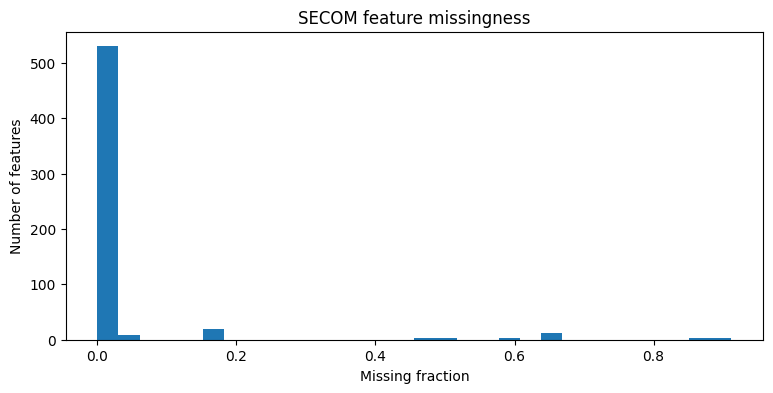

In [6]:
# 5. Data quality

missing_fraction = X.isna().mean()
constant_features = X.columns[X.nunique(dropna=True) <= 1].tolist()

print("Number of features:", X.shape[1])
print("Constant features:", len(constant_features))
print("Features >50% missing:", int((missing_fraction > 0.50).sum()))
print("Total missing cells:", int(X.isna().sum().sum()))

plt.figure(figsize=(9, 4))
plt.hist(missing_fraction, bins=30)
plt.xlabel("Missing fraction")
plt.ylabel("Number of features")
plt.title("SECOM feature missingness")
plt.show()


In [7]:
# 6. Untouched stratified test split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=SEED
)

print("Train shape:", X_train.shape)
print("Test shape :", X_test.shape)
print("Train failures:", int(y_train.sum()))
print("Test failures :", int(y_test.sum()))
print(f"Train failure rate: {y_train.mean():.2%}")
print(f"Test failure rate : {y_test.mean():.2%}")


Train shape: (1253, 590)
Test shape : (314, 590)
Train failures: 83
Test failures : 21
Train failure rate: 6.62%
Test failure rate : 6.69%


## 7. Leakage-free statistical feature selector

The selector is fitted separately in each CV training fold.

Within the fold it performs:
1. constant-feature removal
2. missingness filtering
3. temporary median imputation for statistical testing
4. Mann–Whitney U test
5. Benjamini–Hochberg FDR correction
6. robust median-difference effect size
7. rank-based AUC
8. feature ranking
9. Spearman redundancy pruning

The selected features are then passed to the downstream model.


In [8]:
class StatisticalFeatureSelector(BaseEstimator, TransformerMixin):
    def __init__(
        self,
        missing_threshold=0.50,
        fdr_alpha=0.05,
        min_effect=0.15,
        max_features=80,
        corr_threshold=0.90,
        min_features=10
    ):
        self.missing_threshold = missing_threshold
        self.fdr_alpha = fdr_alpha
        self.min_effect = min_effect
        self.max_features = max_features
        self.corr_threshold = corr_threshold
        self.min_features = min_features

    @staticmethod
    def bh_adjust(p):
        p = np.asarray(p, dtype=float)
        n = len(p)

        order = np.argsort(p)
        ranked = p[order]

        q = ranked * n / np.arange(1, n + 1)
        q = np.minimum.accumulate(q[::-1])[::-1]
        q = np.clip(q, 0, 1)

        out = np.empty(n)
        out[order] = q
        return out

    @staticmethod
    def rank_auc(a, b):
        n0, n1 = len(a), len(b)

        if n0 == 0 or n1 == 0:
            return 0.5

        values = np.concatenate([a, b])
        ranks = pd.Series(values).rank(method="average").to_numpy()

        # Positive-class rank sum -> Mann-Whitney U
        u = ranks[n0:].sum() - n1 * (n1 + 1) / 2
        auc = u / (n0 * n1)

        # Symmetric with respect to class direction
        return float(max(auc, 1 - auc))

    def fit(self, X, y):
        X = pd.DataFrame(X).copy()
        y = pd.Series(np.asarray(y)).reset_index(drop=True)
        X.reset_index(drop=True, inplace=True)

        self.feature_names_in_ = np.asarray(X.columns, dtype=object)

        # 1. Remove constant features using only this training fold.
        nonconstant = X.nunique(dropna=True) > 1
        candidates = X.columns[nonconstant].tolist()

        # 2. Missingness filter using only this training fold.
        candidates = [
            c for c in candidates
            if X[c].isna().mean() <= self.missing_threshold
        ]

        if not candidates:
            raise ValueError("No features survived quality filtering.")

        # 3. Temporary imputation for tests only.
        Xi = X[candidates].replace([np.inf, -np.inf], np.nan)
        Xi = Xi.fillna(Xi.median()).fillna(0)

        neg = y.to_numpy() == 0
        pos = y.to_numpy() == 1

        rows = []

        for feature in candidates:
            a = Xi.loc[neg, feature].to_numpy()
            b = Xi.loc[pos, feature].to_numpy()

            try:
                _, p_value = mannwhitneyu(
                    a, b,
                    alternative="two-sided"
                )
                auc = self.rank_auc(a, b)
            except Exception:
                p_value = 1.0
                auc = 0.5

            scale = np.nanstd(
                Xi[feature].to_numpy(),
                ddof=1
            )

            if not np.isfinite(scale) or scale <= 1e-12:
                effect = 0.0
            else:
                effect = (
                    abs(np.nanmedian(b) - np.nanmedian(a))
                    / scale
                )

            rows.append(
                (feature, p_value, effect, auc)
            )

        stats = pd.DataFrame(
            rows,
            columns=["feature", "p_value", "effect", "auc"]
        )

        stats["q_value"] = self.bh_adjust(stats["p_value"])
        stats["auc_distance"] = (stats["auc"] - 0.5).abs()

        # Primary statistical gate.
        selected = stats[
            (stats["q_value"] <= self.fdr_alpha) &
            (stats["effect"] >= self.min_effect)
        ].copy()

        # Robust fallback if the statistical gate is too strict.
        if len(selected) < self.min_features:
            selected = stats.sort_values(
                ["q_value", "auc_distance", "effect"],
                ascending=[True, False, False]
            ).head(
                min(self.max_features, len(stats))
            )

        selected = selected.sort_values(
            ["q_value", "auc_distance", "effect"],
            ascending=[True, False, False]
        ).head(self.max_features)

        names = selected["feature"].tolist()

        # Spearman redundancy pruning.
        if len(names) > 1:
            corr = Xi[names].corr(method="spearman").abs()

            kept = []

            for feature in names:
                if all(
                    corr.loc[feature, previous] < self.corr_threshold
                    for previous in kept
                ):
                    kept.append(feature)

            names = kept

        if not names:
            names = [
                stats.sort_values("q_value").iloc[0]["feature"]
            ]

        self.selected_features_ = names
        self.statistics_ = (
            stats.sort_values("q_value")
            .reset_index(drop=True)
        )

        return self

    def transform(self, X):
        X = pd.DataFrame(X).copy()

        missing = [
            c for c in self.selected_features_
            if c not in X.columns
        ]

        if missing:
            raise ValueError(
                f"Missing selected features: {missing[:5]}"
            )

        return X[self.selected_features_].copy()

    def get_feature_names_out(self, input_features=None):
        return np.asarray(
            self.selected_features_,
            dtype=object
        )


## 8. Define the two models

Both models use the **same statistical feature-selection pipeline**.

The difference is the model itself:

- Logistic Regression: linear, highly interpretable
- Extra Trees: nonlinear, interaction-capable ensemble


In [9]:
def new_selector():
    return StatisticalFeatureSelector(
        missing_threshold=0.50,
        fdr_alpha=0.05,
        min_effect=0.15,
        max_features=80,
        corr_threshold=0.90,
        min_features=10
    )


logistic_pipeline = Pipeline([
    ("selector", new_selector()),
    ("imputer", SimpleImputer(
        strategy="median",
        add_indicator=True
    )),
    ("scaler", RobustScaler()),
    ("model", LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        C=0.5,
        solver="liblinear",
        random_state=SEED
    ))
])


extra_trees_pipeline = Pipeline([
    ("selector", new_selector()),
    ("imputer", SimpleImputer(
        strategy="median",
        add_indicator=True
    )),
    ("model", ExtraTreesClassifier(
        n_estimators=500,
        min_samples_leaf=2,
        max_features="sqrt",
        class_weight="balanced",
        n_jobs=-1,
        random_state=SEED
    ))
])


models = {
    "Logistic Regression": logistic_pipeline,
    "Extra Trees": extra_trees_pipeline
}

print("Models ready:")
for name in models:
    print(" -", name)


Models ready:
 - Logistic Regression
 - Extra Trees


In [10]:
# 9. 5-fold out-of-fold probability evaluation

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=SEED
)

oof_probabilities = {}
cv_rows = []

def evaluate_predictions(y_true, probability, threshold=0.50, name="Model"):
    prediction = (probability >= threshold).astype(int)

    return {
        "model": name,
        "threshold": threshold,
        "balanced_accuracy": balanced_accuracy_score(
            y_true, prediction
        ),
        "roc_auc": roc_auc_score(
            y_true, probability
        ),
        "pr_auc": average_precision_score(
            y_true, probability
        ),
        "recall": recall_score(
            y_true, prediction,
            zero_division=0
        ),
        "precision": precision_score(
            y_true, prediction,
            zero_division=0
        ),
        "f1": f1_score(
            y_true, prediction,
            zero_division=0
        )
    }


for name, model in models.items():
    print("Running:", name)

    prob = cross_val_predict(
        model,
        X_train,
        y_train,
        cv=cv,
        method="predict_proba",
        n_jobs=1
    )[:, 1]

    oof_probabilities[name] = prob

    cv_rows.append(
        evaluate_predictions(
            y_train,
            prob,
            threshold=0.50,
            name=name
        )
    )

cv_results = pd.DataFrame(cv_rows)

display(
    cv_results[
        [
            "model",
            "threshold",
            "balanced_accuracy",
            "roc_auc",
            "pr_auc",
            "recall",
            "precision",
            "f1"
        ]
    ].round(4)
)


Running: Logistic Regression
Running: Extra Trees


,model,threshold,balanced_accuracy,roc_auc,pr_auc,recall,precision,f1
0,Logistic Regression,0.5,0.6256,0.6287,0.1114,0.494,0.1262,0.201
1,Extra Trees,0.5,0.4996,0.7142,0.1716,0.000,0.0000,0.000


## 10. Threshold optimization using OOF training predictions

The threshold is selected using **only the training-set OOF predictions**.

The test set is not involved.


In [11]:
def optimize_threshold(y_true, probability):
    rows = []

    for threshold in np.linspace(0.02, 0.80, 157):
        pred = (probability >= threshold).astype(int)

        rows.append({
            "threshold": threshold,
            "balanced_accuracy": balanced_accuracy_score(
                y_true, pred
            ),
            "recall": recall_score(
                y_true, pred,
                zero_division=0
            ),
            "precision": precision_score(
                y_true, pred,
                zero_division=0
            ),
            "f1": f1_score(
                y_true, pred,
                zero_division=0
            )
        })

    df = pd.DataFrame(rows)

    # Primary objective = balanced accuracy.
    # Tie-breakers = recall, then precision.
    best = df.sort_values(
        ["balanced_accuracy", "recall", "precision"],
        ascending=[False, False, False]
    ).iloc[0]

    return float(best["threshold"]), df


thresholds = {}
threshold_tables = []

for name, probability in oof_probabilities.items():
    threshold, table = optimize_threshold(
        y_train,
        probability
    )

    thresholds[name] = threshold
    threshold_tables.append(
        table.assign(model=name)
    )

    print(f"{name}: selected threshold = {threshold:.3f}")

threshold_results = pd.concat(
    threshold_tables,
    ignore_index=True
)


Logistic Regression: selected threshold = 0.445
Extra Trees: selected threshold = 0.135


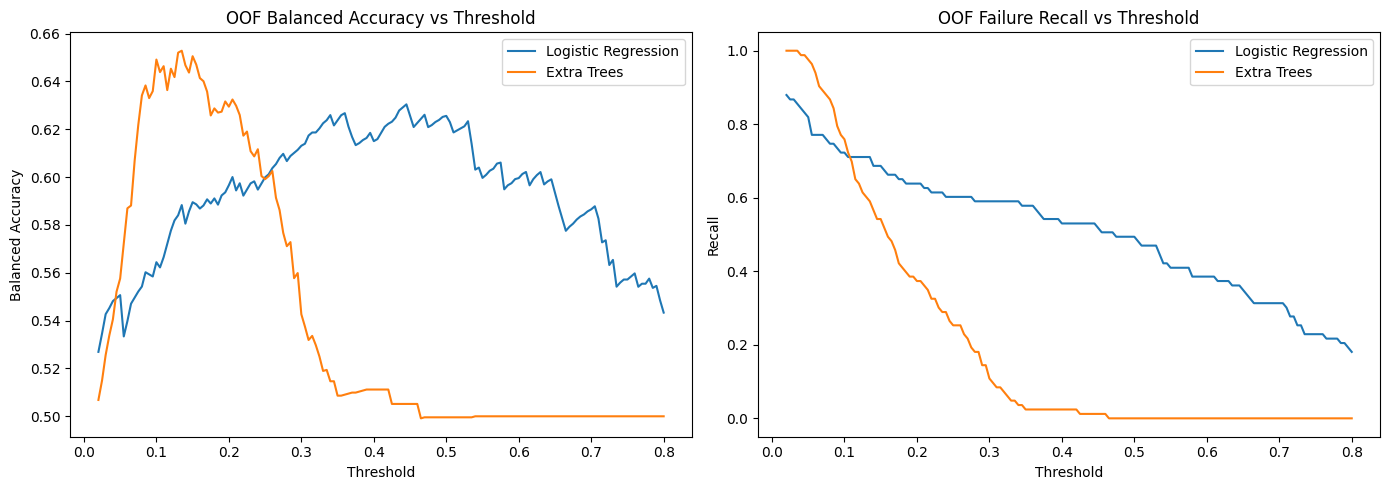

In [12]:
# 11. Visualize threshold trade-offs

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for name in models:
    temp = threshold_results[
        threshold_results["model"] == name
    ]

    axes[0].plot(
        temp["threshold"],
        temp["balanced_accuracy"],
        label=name
    )

    axes[1].plot(
        temp["threshold"],
        temp["recall"],
        label=name
    )

axes[0].set_title("OOF Balanced Accuracy vs Threshold")
axes[0].set_xlabel("Threshold")
axes[0].set_ylabel("Balanced Accuracy")
axes[0].legend()

axes[1].set_title("OOF Failure Recall vs Threshold")
axes[1].set_xlabel("Threshold")
axes[1].set_ylabel("Recall")
axes[1].legend()

plt.tight_layout()
plt.show()


## 12. Final evaluation on the untouched test set

Each model is now fitted on all training observations.

The test set is evaluated exactly once per model.

Thresholds were selected before this step.


In [13]:
final_rows = []
final_probabilities = {}
final_predictions = {}

for name, model in models.items():

    print("Fitting final:", name)

    model.fit(X_train, y_train)

    probability = model.predict_proba(
        X_test
    )[:, 1]

    threshold = thresholds[name]
    prediction = (
        probability >= threshold
    ).astype(int)

    final_probabilities[name] = probability
    final_predictions[name] = prediction

    row = evaluate_predictions(
        y_test,
        probability,
        threshold=threshold,
        name=name
    )

    final_rows.append(row)

final_results = pd.DataFrame(final_rows)

display(
    final_results[
        [
            "model",
            "threshold",
            "balanced_accuracy",
            "roc_auc",
            "pr_auc",
            "recall",
            "precision",
            "f1"
        ]
    ].sort_values(
        ["pr_auc", "balanced_accuracy"],
        ascending=False
    ).round(4)
)


Fitting final: Logistic Regression
Fitting final: Extra Trees


,model,threshold,balanced_accuracy,roc_auc,pr_auc,recall,precision,f1
1,Extra Trees,0.135,0.7530,0.8059,0.2718,0.7619,0.1758,0.2857
0,Logistic Regression,0.445,0.6271,0.6504,0.1322,0.5238,0.1222,0.1982


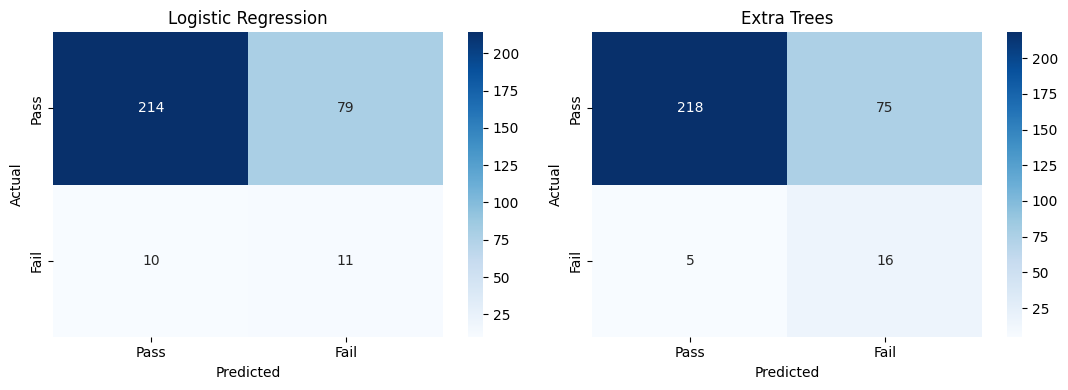

In [14]:
# 13. Confusion matrices

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, name in zip(axes, models.keys()):
    cm = confusion_matrix(
        y_test,
        final_predictions[name]
    )

    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Pass", "Fail"],
        yticklabels=["Pass", "Fail"],
        ax=ax
    )

    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()


In [15]:
# 14. Detailed reports

for name in models:
    print("=" * 70)
    print(name)
    print("=" * 70)

    print(
        classification_report(
            y_test,
            final_predictions[name],
            target_names=["Pass", "Fail"],
            zero_division=0
        )
    )


Logistic Regression
              precision    recall  f1-score   support

        Pass       0.96      0.73      0.83       293
        Fail       0.12      0.52      0.20        21

    accuracy                           0.72       314
   macro avg       0.54      0.63      0.51       314
weighted avg       0.90      0.72      0.79       314

Extra Trees
              precision    recall  f1-score   support

        Pass       0.98      0.74      0.84       293
        Fail       0.18      0.76      0.29        21

    accuracy                           0.75       314
   macro avg       0.58      0.75      0.57       314
weighted avg       0.92      0.75      0.81       314



## 15. Model comparison

Interpret the result using:
- **Balanced Accuracy** for class-balanced classification quality
- **ROC-AUC** for ranking quality
- **PR-AUC** because failures are rare
- **Failure Recall** for missed-failure sensitivity
- **Precision** for false-alarm burden
- **F1** for recall/precision balance

Do not select a model from raw accuracy alone.


In [16]:
# 15. Direct comparison

comparison = final_results.copy()

display(
    comparison[
        [
            "model",
            "balanced_accuracy",
            "roc_auc",
            "pr_auc",
            "recall",
            "precision",
            "f1"
        ]
    ].sort_values(
        ["pr_auc", "balanced_accuracy"],
        ascending=False
    ).round(4)
)

best_by_pr = comparison.sort_values(
    ["pr_auc", "balanced_accuracy"],
    ascending=False
).iloc[0]

print("Current test-set leader by PR-AUC:", best_by_pr["model"])


,model,balanced_accuracy,roc_auc,pr_auc,recall,precision,f1
1,Extra Trees,0.7530,0.8059,0.2718,0.7619,0.1758,0.2857
0,Logistic Regression,0.6271,0.6504,0.1322,0.5238,0.1222,0.1982


Current test-set leader by PR-AUC: Extra Trees


## 16. Statistical candidate process signals

Fit the selector on the training set only for interpretation.

These are **candidate signals associated with failure**, not proof of causal root cause.


In [17]:
# Use the selector from each final fitted model.
for name, model in models.items():
    selector = model.named_steps["selector"]

    print("\n" + "="*70)
    print(name)
    print("="*70)
    print("Selected signals:", len(selector.selected_features_))

    selected_stats = selector.statistics_[
        selector.statistics_["feature"].isin(
            selector.selected_features_
        )
    ].copy()

    display(
        selected_stats[
            ["feature", "p_value", "q_value", "effect", "auc"]
        ].round(5)
    )



Logistic Regression
Selected signals: 56


,feature,p_value,q_value,effect,auc
0,Sensor_104,0.00000,0.00001,0.79926,0.68147
1,Sensor_60,0.00000,0.00024,0.41883,0.65998
2,Sensor_478,0.00002,0.00256,0.11624,0.63896
3,Sensor_511,0.00002,0.00256,0.37196,0.64102
5,Sensor_34,0.00009,0.00660,0.10300,0.62832
6,Sensor_248,0.00010,0.00660,0.00000,0.62131
7,Sensor_130,0.00017,0.00962,0.11607,0.62319
10,Sensor_96,0.00039,0.01600,0.95399,0.60919
11,Sensor_317,0.00084,0.03163,0.32709,0.60951
12,Sensor_22,0.00108,0.03233,0.15709,0.60725



Extra Trees
Selected signals: 56


,feature,p_value,q_value,effect,auc
0,Sensor_104,0.00000,0.00001,0.79926,0.68147
1,Sensor_60,0.00000,0.00024,0.41883,0.65998
2,Sensor_478,0.00002,0.00256,0.11624,0.63896
3,Sensor_511,0.00002,0.00256,0.37196,0.64102
5,Sensor_34,0.00009,0.00660,0.10300,0.62832
6,Sensor_248,0.00010,0.00660,0.00000,0.62131
7,Sensor_130,0.00017,0.00962,0.11607,0.62319
10,Sensor_96,0.00039,0.01600,0.95399,0.60919
11,Sensor_317,0.00084,0.03163,0.32709,0.60951
12,Sensor_22,0.00108,0.03233,0.15709,0.60725


In [18]:
# 17. Feature interpretation

for name, model in models.items():

    print("\n" + "="*70)
    print(name)
    print("="*70)

    selector = model.named_steps["selector"]
    imputer = model.named_steps["imputer"]
    final_model = model.named_steps["model"]

    try:
        feature_names = imputer.get_feature_names_out(
            selector.selected_features_
        )

        if hasattr(final_model, "coef_"):
            coef = np.ravel(final_model.coef_)

            coef_df = pd.DataFrame({
                "feature": feature_names,
                "coefficient": coef,
                "absolute_coefficient": np.abs(coef)
            }).sort_values(
                "absolute_coefficient",
                ascending=False
            )

            display(coef_df.head(20))

        elif hasattr(final_model, "feature_importances_"):
            imp = pd.DataFrame({
                "feature": feature_names,
                "importance": final_model.feature_importances_
            }).sort_values(
                "importance",
                ascending=False
            )

            display(imp.head(20))

    except Exception as exc:
        print("Feature-name mapping skipped:", exc)



Logistic Regression


,feature,coefficient,absolute_coefficient
84,missingindicator_Sensor_57,1.398753,1.398753
89,missingindicator_Sensor_41,-1.013399,1.013399
54,Sensor_122,0.975482,0.975482
21,Sensor_184,0.611639,0.611639
18,Sensor_125,-0.574270,0.574270
6,Sensor_130,0.564492,0.564492
33,Sensor_512,0.531123,0.531123
10,Sensor_22,0.516455,0.516455
93,missingindicator_Sensor_291,-0.497366,0.497366
29,Sensor_57,0.489031,0.489031



Extra Trees


,feature,importance
0,Sensor_104,0.028346
6,Sensor_130,0.026707
33,Sensor_512,0.023715
45,Sensor_500,0.022250
27,Sensor_131,0.022041
1,Sensor_60,0.021942
18,Sensor_125,0.020779
54,Sensor_122,0.020771
12,Sensor_123,0.020368
21,Sensor_184,0.020357


# 19. Final interpretation


### Logistic Regression
A strong, interpretable baseline. Coefficients provide a transparent direction of association for candidate signals.

### Extra Trees
A nonlinear ensemble that can capture interactions among process measurements and may provide stronger predictive ranking.

### Conclusion
We compared an interpretable linear model with a nonlinear ensemble using leakage-controlled feature selection, imbalance-aware modeling and OOF threshold selection.
